# Phase Space Representation of a Time Series

## Objective
Explore how a time series can be represented geometrocally using a phase space plot.

Instead of examining the signal only as a function of time, we construct a representation that compares the signal to a delayed version of itself. This allows us to observe patterns in the system's dynamics and visualize the trajectory of the system state. 

Phase space representations are wiely used in dynamical systems analysis because they reveal structures that not be obvious in the time-domain signal. 

----------------------------------------------------------------------------
## Method Overview 
This notebook proceeds in three steps:
1. Recreate the synthetic system and Kalman estimate from previous exercises.
2. Construct a delayed version of the signal.
3. Plot the signal against its delayed version to visualize the system trajectory. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(72)

In [4]:
t = np.arange(0, 200)

true_signal = np.sin(2*np.pi*t/30)

noise = np.random.normal(0, 0.04, len(t))

observations = true_signal + noise

In [7]:
x = np.zeros(len(t))
P = np.zeros(len(t))

Q = 0.01
R = 0.2

for i in range (1, len(t)):

    x_pred = x[i - 1]
    P_pred = P[i - 1] + Q

    K = P_pred/(P_pred + R)

    x[i] = x_pred + K*(observations[i] - x_pred)
    P[i] = (1 - K)*P_pred

### Construct a Delayed Signal, Phase Space Plot
To visualize the phase relationship of the system, we compare the signal to a delayed version of itself. 

For this example, we introduce a delay of *one time step*.

In [8]:
x_t = x[:-1]
x_t1 = x[1:]

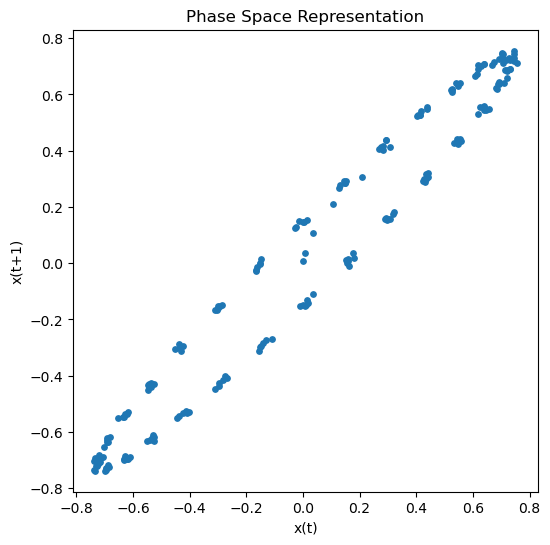

In [9]:
plt.figure(figsize=(6,6))

plt.scatter(x_t, x_t1, s=15)

plt.title("Phase Space Representation")
plt.xlabel("x(t)")
plt.ylabel("x(t+1)")

plt.show()

### Compare Phase Space Across Signals
To show how filtering changes the geometry, we will chech 3 different phase protraits:

1. True signal
2. Observations (noisy)
3. Kalman Estimate


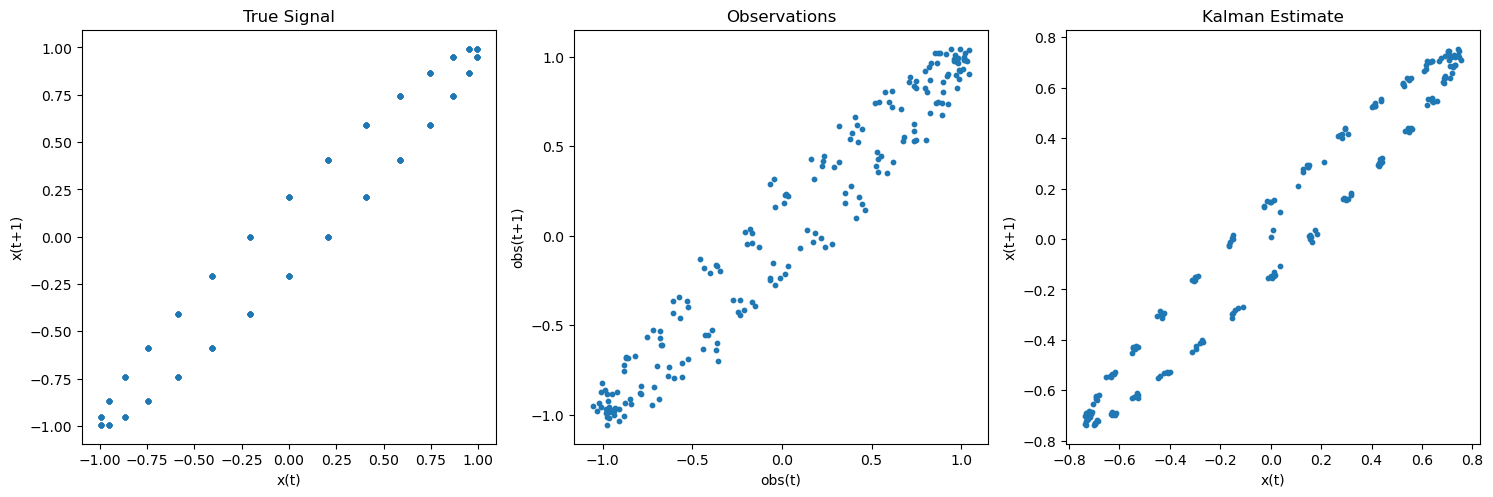

In [17]:
true_t = true_signal[:-1]
true_t1 = true_signal[1:]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# True Signal
axes[0].scatter(true_signal[:-1], true_signal[1:], s=10)
axes[0].set_title("True Signal")
axes[0].set_xlabel("x(t)")
axes[0].set_ylabel("x(t+1)")

# Observations
axes[1].scatter(observations[:-1], observations[1:], s=10)
axes[1].set_title("Observations")
axes[1].set_xlabel("obs(t)")
axes[1].set_ylabel("obs(t+1)")

# Kalman  estimate
axes[2].scatter(x[:-1], x[1:], s=10)
axes[2].set_title("Kalman Estimate")
axes[2].set_xlabel("x(t)")
axes[2].set_ylabel("x(t+1)")

for ax in axes:
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

*Filtering restored the system's geometry by recovering the structure of the underlying dynamics*

## Summary

This notebook explored how a time series can be represented as a geometric trajectory using a phase space plot. By plotting the estimated signal against a delaed version of itself, we observed that the oscillatory system forms an elliptical orbit n phase space.

Comparing phase portraits of the true signal, noisey observations, and Kalman-filtered estimate revealed how much measurement noise distorts the geometric structure of the system. Te filtered estimate produced a clearer approximation of the underlying orbit, demonstrating how state estimation can help recover the system's dynamics from noisy data. 

This geometric representation provides an alternative perspective ob oscillatory signals that complements both time-domain visualization and frequency-domain analysis. 

----------------------------------------------------------------------------

### Key Takeaways
* A time series can be represented geometrically by plotting delayed versions of the signal against each other.
* Oscillatory systems produce characteristic phase-space orbits.
* Measurement noise distorts the shape of these trajectories.
* State estimation methods such as the Kalman filter can help reveal the underlying structure of the system. 